# Лабоработрная работа 1

<b> Студент группы 2301-05-00 <br>
Ковальский Иван Иванович

Вариант 10

## Задание

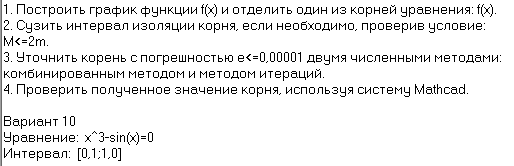

## Начальные условия

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# --- Условия

def f(x):
    #Основная функция f(x) = x^3 - sin(x)
    return x**3 - np.sin(x)

def df(x):
    #Первая производная f'(x) = 3x^2 - cos(x)
    return 3*x**2 - np.cos(x)

def d2f(x):
    #Вторая производная f''(x) = 6x + sin(x)
    return 6*x + np.sin(x)

initial_a = 0.1  # Начало исходного интервала
initial_b = 1.0  # Конец исходного интервала
epsilon = 0.00001 # Допустимая погрешность

def print(string):
    display(Markdown(string))



x_vals = np.linspace(initial_a, initial_b, 400)
y_f = f(x_vals)
y_df = df(x_vals)
y_d2f = d2f(x_vals)

## 1. Локализация корня и проверка условий

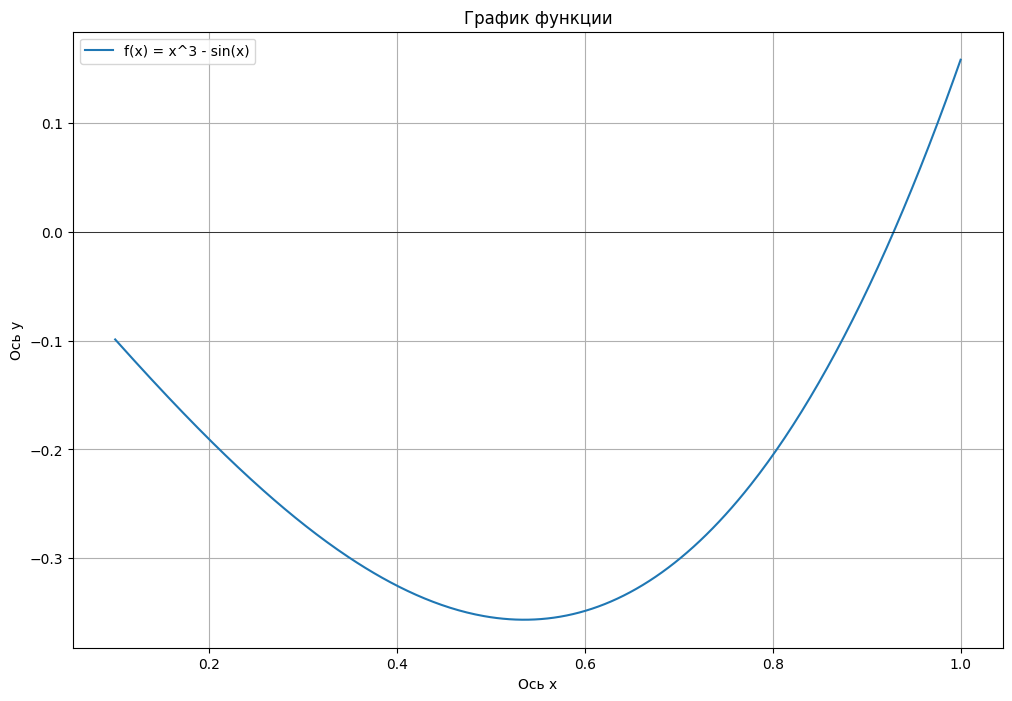

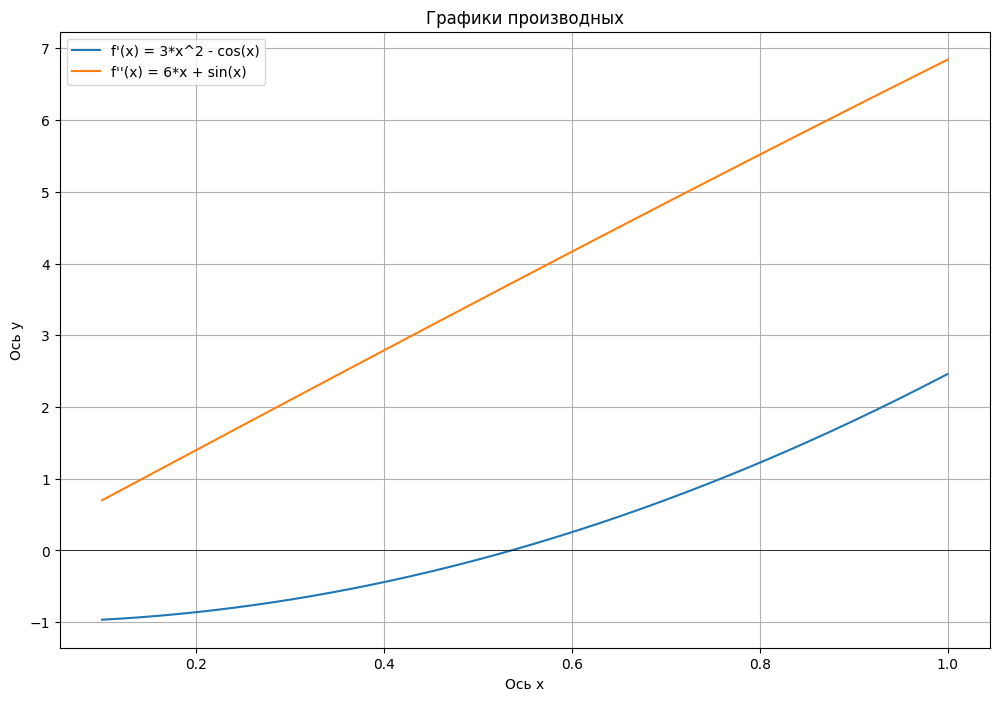

In [46]:
def daraw(x_vals):
    y_f=f(x_vals)
    plt.figure(figsize=(12, 8))
    plt.plot(x_vals, y_f, label="f(x) = x^3 - sin(x)")

    plt.axhline(0, color='black', linewidth=0.5)
    plt.title("График функции")
    plt.xlabel("Ось x")
    plt.ylabel("Ось y")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 8))
    plt.plot(x_vals, y_df, label="f'(x) = 3*x^2 - cos(x)")
    plt.plot(x_vals, y_d2f, label="f''(x) = 6*x + sin(x)")
    plt.axhline(0, color='black', linewidth=0.5)
    plt.title("Графики производных")
    plt.xlabel("Ось x")
    plt.ylabel("Ось y")
    plt.grid(True)
    plt.legend()
    plt.show()

daraw(x_vals)


In [47]:
for i in range(len(y_f) - 1):
    pairs=[]
    y1, y2 = y_f[i], y_f[i + 1]
    # Если знаки разные: произведение отрицательно -> знак меняется, корень где то между
    if y1 * y2 < 0:
        print(f"Уточнённая область корня от <br> {x_vals[i]} <br>(f(x)={y1}) <br> до <br> {x_vals[i+1]} <br>(f(x)={y2})")
#применим примерно уточнённые значения
corre_a=0.8
corre_b=1.

Уточнённая область корня от <br> 0.9278195488721804 <br>(f(x)=-0.001601850762535162) <br> до <br> 0.9300751879699248 <br>(f(x)=0.0028872174571592524)

Из графиков на уточнённом промежутке [0.8;1.0] делаем выводы:
<br> 1) Возрастает (значения f'(x) на [0,8;1.0])
<br> 2) Вогнутая (значения f''(x) на [0,8;1.0])
<br> 3) Функция непрерывна т.к x^3 и sin(x) непрерывны

## 2. Условие M < 2m

In [48]:
x_plt = np.linspace(corre_a, corre_b, 200)
m = min(df(x_plt))
M = max(d2f(x_plt))

condition = M < 2 * m
#второе
# чтобы выбрать формулу определения погрешности
# M-максимум второй производной
# m-минимум первой производной
print(f"Интервал [{corre_a}, {corre_b}]:")
print(f"*   m = min|f' (x)| ≈ {m}")
print(f"*   M = max|f'' (x)| ≈ {M}")
print(f"*   Условие: {M} < {2*m}")
if condition:
    print(f"*   **Условия выполнены**")
else:
    print(f"*   **Условия не выполнены**")

Интервал [0.8, 1.0]:

*   m = min|f' (x)| ≈ 1.223293290652835

*   M = max|f'' (x)| ≈ 6.841470984807897

*   Условие: 6.841470984807897 < 2.44658658130567

*   **Условия не выполнены**

## 3. Комбинированный метод


In [49]:
def combined_method(a_start, b_start, eps):
    a_n, b_n = a_start, b_start
    iterations = 0
    history = [(a_n, b_n)]

    while abs(b_n - a_n) > eps:
        iterations += 1

        # Метод хорд для a_n
        a_next = a_n - f(a_n) * (b_n - a_n) / (f(b_n) - f(a_n))

        # Метод Ньютона для b_n
        b_next = b_n - f(b_n) / df(b_n)

        print("---")

        print(f"итерация: {iterations} |<br> хорда a_n {a_next:.6f} ||<br> касательная {b_next:.6f} ||<br>  погрешность: {abs(b_next-a_next):.10e}")

        print("---")

        a_n, b_n = a_next, b_next
        history.append((a_n, b_n))

        if iterations > 50:
            print("Куда то не туда пошло")
            break

    root = (a_n + b_n) / 2

    print(f"\n**Корень, найденный комбинированным методом:<br>x ≈ {root:.5f}** <br>с погрешностью:{eps}")

    return root, history

# Вызываем метод
combined_root, combined_history = combined_method(corre_a, corre_b, epsilon)

---

итерация: 1 |<br> хорда a_n 0.912869 ||<br> касательная 0.935549 ||<br>  погрешность: 2.2680747524e-02

---

---

итерация: 2 |<br> хорда a_n 0.928450 ||<br> касательная 0.928702 ||<br>  погрешность: 2.5228926614e-04

---

---

итерация: 3 |<br> хорда a_n 0.928626 ||<br> касательная 0.928626 ||<br>  погрешность: 3.0528423345e-08

---


**Корень, найденный комбинированным методом:<br>x ≈ 0.92863** <br>с погрешностью:1e-05

### 3.1. Визуализация первых двух шагов

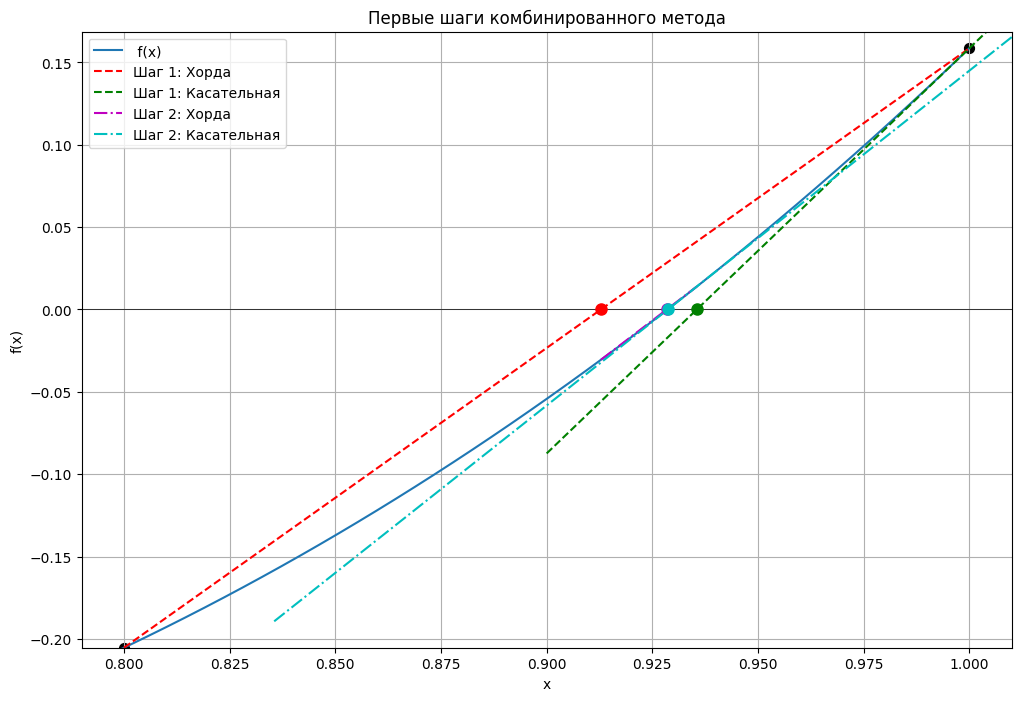

In [50]:
x_plt = np.linspace(0.1, 1., 200)
y_plt = f(x_plt)

#  график функции
plt.figure(figsize=(12, 8))
plt.plot(x_plt, y_plt, label=" f(x) ")
plt.axhline(0, color='black', linewidth=0.5)
#  график функции


# Шаг 1
a0, b0 = combined_history[0]
a1, b1 = combined_history[1]
# Хорда 1
plt.plot([a0, b0], [f(a0), f(b0)], 'r--', label="Шаг 1: Хорда")
# Касательная 1
x_tan1 = np.linspace(b0 - 0.1, b0 + 0.1, 10)
y_tan1 = f(b0) + df(b0) * (x_tan1 - b0)
plt.plot(x_tan1, y_tan1, 'g--', label="Шаг 1: Касательная")
plt.plot(a1, 0, 'ro', markersize=8)
plt.plot(b1, 0, 'go', markersize=8)

# Шаг 2
a2, b2 = combined_history[2]
# Хорда 2
plt.plot([a1, b1], [f(a1), f(b1)], 'm-.', label="Шаг 2: Хорда")
# Касательная 2
x_tan2 = np.linspace(b1 - 0.1, b1 + 0.1, 10)
y_tan2 = f(b1) + df(b1) * (x_tan2 - b1)
plt.plot(x_tan2, y_tan2, 'c-.', label="Шаг 2: Касательная")
plt.plot(a2, 0, 'mo', markersize=8)
plt.plot(b2, 0, 'co', markersize=8)

plt.xlim(a0-0.01, b0+0.01)
plt.ylim(min(f(a0),f(b0)-0.01),max(f(a0),f(b0))+0.01)
plt.scatter([a0, b0], [f(a0), f(b0)], color='black', s=50)
plt.title("Первые шаги комбинированного метода")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

## 4. Метод Ньютона


In [51]:
def newton_method(x0, eps):
    x_prev = x0
    iterations = 0

    while True:
        iterations += 1
        x_next = x_prev - f(x_prev) / df(x_prev)
        diff = abs(x_next - x_prev)

        print(f"Итерация: {iterations:<8}<br> $x_n$ {x_next:<18.10f}<br>" "|$x_n$ - $x_{n-1}$|=" f"{diff:<18.10e}<br>")

        print("---")

        if diff < eps:
            break

        x_prev = x_next
        if iterations > 50:
            print("Куда то не туда")
            break

    print(f"\n**Корень: x ≈ {x_next:.8f}**")
    return x_next, iterations

### 4.1. Решение с правильным начальным приближением x_0 = 1.0

In [52]:
newton_root_b, newton_iter_b = newton_method(corre_b, epsilon)

Итерация: 1       <br> $x_n$ 0.9355493907      <br>|$x_n$ - $x_{n-1}$|=6.4450609345e-02  <br>

---

Итерация: 2       <br> $x_n$ 0.9287018088      <br>|$x_n$ - $x_{n-1}$|=6.8475818508e-03  <br>

---

Итерация: 3       <br> $x_n$ 0.9286263179      <br>|$x_n$ - $x_{n-1}$|=7.5490938186e-05  <br>

---

Итерация: 4       <br> $x_n$ 0.9286263087      <br>|$x_n$ - $x_{n-1}$|=9.1339034114e-09  <br>

---


**Корень: x ≈ 0.92862631**

### 4.2. Решение с другим начальным приближением x_0 = 0.85

In [53]:
newton_root_085, newton_iter_085 = newton_method(0.85, epsilon)

Итерация: 1       <br> $x_n$ 0.9409810094      <br>|$x_n$ - $x_{n-1}$|=9.0981009443e-02  <br>

---

Итерация: 2       <br> $x_n$ 0.9288635676      <br>|$x_n$ - $x_{n-1}$|=1.2117441822e-02  <br>

---

Итерация: 3       <br> $x_n$ 0.9286263989      <br>|$x_n$ - $x_{n-1}$|=2.3716872621e-04  <br>

---

Итерация: 4       <br> $x_n$ 0.9286263087      <br>|$x_n$ - $x_{n-1}$|=9.0163342126e-08  <br>

---


**Корень: x ≈ 0.92862631**

### 4.2. Решение с другим начальным приближением x_0 = 0.3

In [54]:
newton_root_085, newton_iter_085 = newton_method(0.3, epsilon)

Итерация: 1       <br> $x_n$ -0.0918078359     <br>|$x_n$ - $x_{n-1}$|=3.9180783589e-01  <br>

---

Итерация: 2       <br> $x_n$ 0.0018602318      <br>|$x_n$ - $x_{n-1}$|=9.3668067670e-02  <br>

---

Итерация: 3       <br> $x_n$ -0.0000000150     <br>|$x_n$ - $x_{n-1}$|=1.8602468001e-03  <br>

---

Итерация: 4       <br> $x_n$ 0.0000000000      <br>|$x_n$ - $x_{n-1}$|=1.5020458932e-08  <br>

---


**Корень: x ≈ 0.00000000**

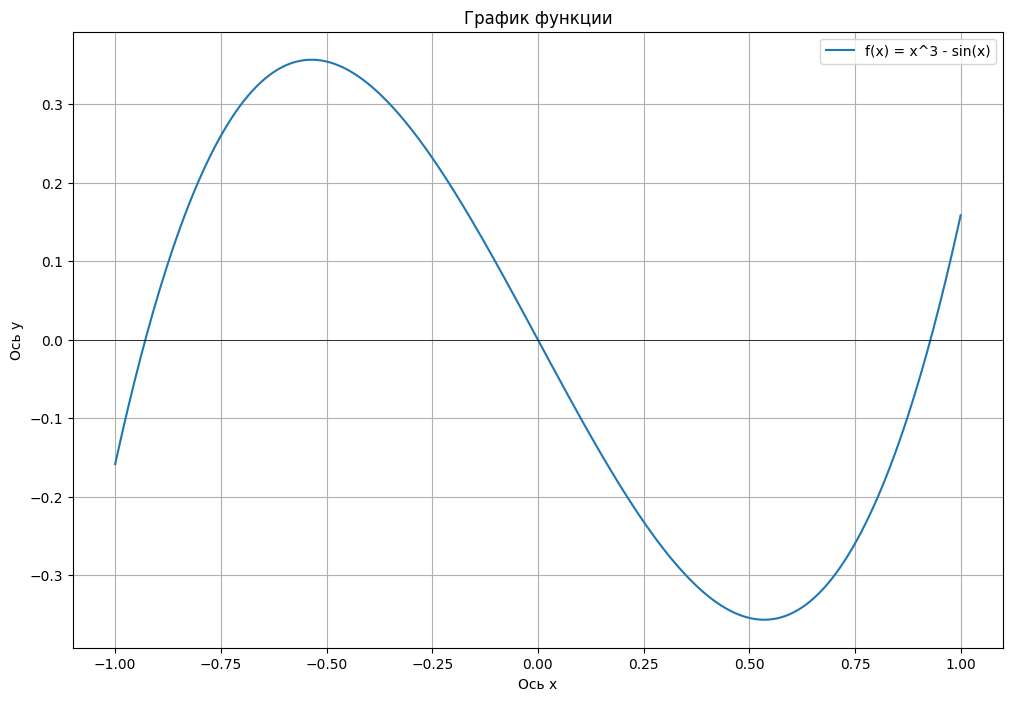

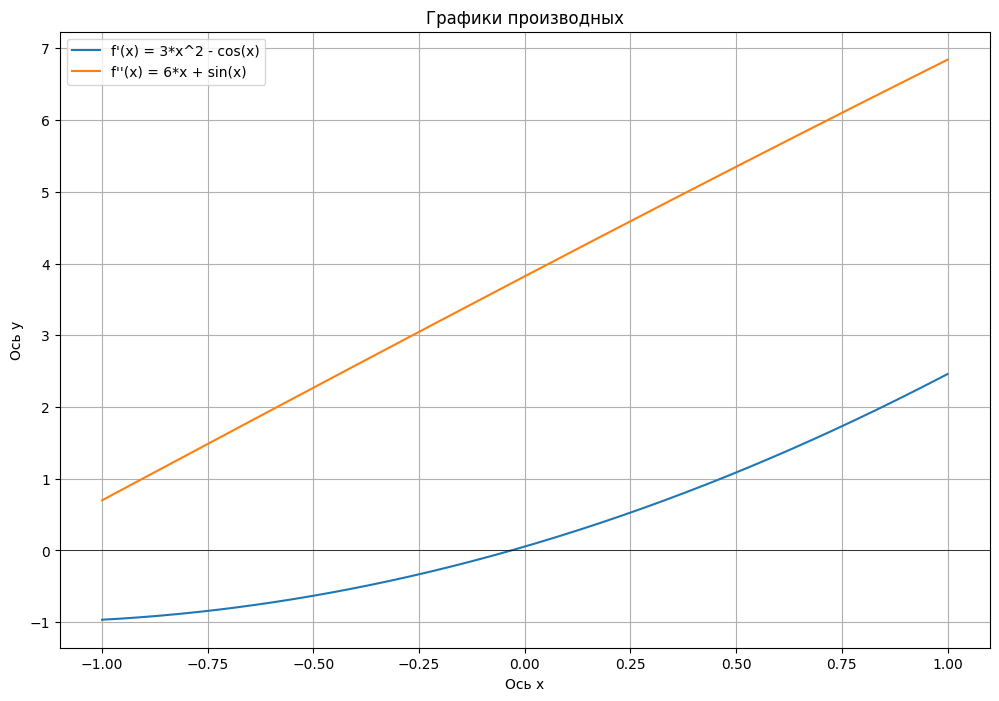

In [55]:
daraw(np.linspace(-1, 1, 400))

Получили 0 т.к это тоже корень (0;0)

### 4.3. Решение с 'неправильным' концом отрезка $x_0$ = 0.8

In [56]:
newton_root_a, newton_iter_a = newton_method(0.8, epsilon)

Итерация: 1       <br> $x_n$ 0.9678715092      <br>|$x_n$ - $x_{n-1}$|=1.6787150920e-01  <br>

---

Итерация: 2       <br> $x_n$ 0.9308731064      <br>|$x_n$ - $x_{n-1}$|=3.6998402759e-02  <br>

---

Итерация: 3       <br> $x_n$ 0.9286343537      <br>|$x_n$ - $x_{n-1}$|=2.2387527307e-03  <br>

---

Итерация: 4       <br> $x_n$ 0.9286263088      <br>|$x_n$ - $x_{n-1}$|=8.0448775659e-06  <br>

---


**Корень: x ≈ 0.92862631**

## 5. Обусловленность задачи

In [57]:
def f_param(x, a_param):
    return a_param * x**3 - np.sin(x)

def df_param(x, a_param):
    return 3 * a_param * x**2 - np.cos(x)

def ob(alpha):
    x_prev = newton_root_b
    x_curr = x_prev - f_param(x_prev, alpha) / df_param(x_prev, alpha)
    while abs(x_curr - x_prev) > epsilon:
        x_prev = x_curr
        x_curr = x_prev - f_param(x_prev, alpha) / df_param(x_prev, alpha)

    new_root = x_curr
    initial_root = combined_root

    delta_alpha_rel = (alpha - 1.0) / 1.0
    delta_x_rel = (new_root - initial_root) / initial_root
    amplification_factor = abs(delta_x_rel / delta_alpha_rel)

    print(f"Исходный корень (при alpha=1.0): **{initial_root:.8f}**")
    print(f"Новый корень (при alpha={alpha}): **{new_root:.8f}**")

    print(f"Относительное изменение параметра alpha: **{delta_alpha_rel:.2%}**")
    print(f"Относительное изменение корня x: **{delta_x_rel:.4%}**")


In [58]:
ob(1.05)

Исходный корень (при alpha=1.0): **0.92862630**

Новый корень (при alpha=1.05): **0.90912355**

Относительное изменение параметра alpha: **5.00%**

Относительное изменение корня x: **-2.1002%**

In [59]:
ob(1.5)

Исходный корень (при alpha=1.0): **0.92862630**

Новый корень (при alpha=1.5): **0.77574802**

Относительное изменение параметра alpha: **50.00%**

Относительное изменение корня x: **-16.4628%**

## 6. Метод простых итераций

In [60]:
m = df(corre_a)
M = df(corre_b)
lambda_opt = 2 / (M + m)

q_opt = abs((M - m) / (M + m))

print(f"m = {m:.4f}, M = {M:.4f}")
print(f"коэффициент **lambda = {lambda_opt:.4f}**")

def simm(x0, eps, lambda_val):
    def phi(x):
        return x - lambda_val * f(x)
    def phid(x):
        return 1-lambda_val*df(x)


    x_plt = np.linspace(corre_a, corre_b, 200)
    y_phi_prime = phid(x_plt)

    plt.figure(figsize=(10, 6))


    plt.title(f"График phi'(x) при lambda = {lambda_val:.4f} ")
    plt.plot(x_plt, abs(y_phi_prime), label=r"phi'(x) = 1 - lambda f'(x) ", color='blue')



    max_abs_phi = np.max(np.abs(y_phi_prime))
    plt.axhline(max_abs_phi, color='green', linestyle=':', label=f"Max |phi'(x) |  ~  {max_abs_phi:.4f}")
    plt.axhline(-max_abs_phi, color='green', linestyle=':')

    plt.xlabel("x")
    plt.ylabel("phi'(x) ")
    plt.grid(True)
    plt.legend()
    plt.show()


    x_prev = x0
    iterations = 0
    print(f"**Расчет для lambda = {lambda_val:.4f}**")

    while True:
        iterations += 1
        x_next = phi(x_prev)
        diff = abs(x_next - x_prev)


        print(f"Итерация: {iterations:<8}<br> $x_n$ = "f"{x_next:<18.10f}<br>""$|x_n - x_{n-1}$| = "f"{diff:<18.10e}")

        if diff < eps:
            break

        x_prev = x_next
        if iterations > 100:
            print("Превышено максимальное число итераций")
            break

    print(f"\n**Корень: x ≈ {x_next:.8f}**")
    print(f"**Количество итераций: {iterations}**")
    return x_next, iterations



m = 1.2233, M = 2.4597

коэффициент **lambda = 0.5430**

### $\lambda$ = $\frac{2}{M + m}$

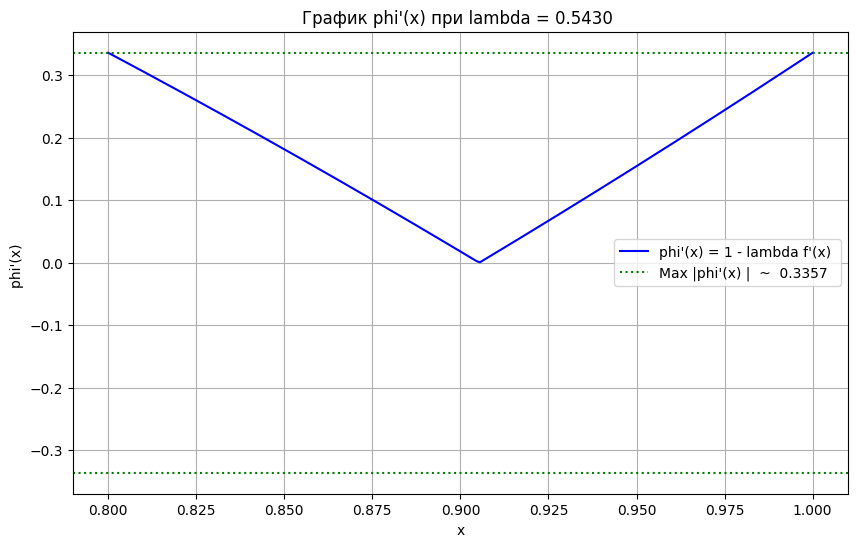

**Расчет для lambda = 0.5430**

Итерация: 1       <br> $x_n$ = 0.9115159346      <br>$|x_n - x_{n-1}$| = 1.1151593460e-01  

Итерация: 2       <br> $x_n$ = 0.9294849805      <br>$|x_n - x_{n-1}$| = 1.7969045927e-02  

Итерация: 3       <br> $x_n$ = 0.9285566696      <br>$|x_n - x_{n-1}$| = 9.2831095106e-04  

Итерация: 4       <br> $x_n$ = 0.9286318447      <br>$|x_n - x_{n-1}$| = 7.5175073499e-05  

Итерация: 5       <br> $x_n$ = 0.9286258679      <br>$|x_n - x_{n-1}$| = 5.9767138109e-06  


**Корень: x ≈ 0.92862587**

**Количество итераций: 5**

In [61]:
iter_root_opt, iter_count_opt = simm(corre_a, epsilon, lambda_opt)
#первое

### $\lambda$ = $1/M$

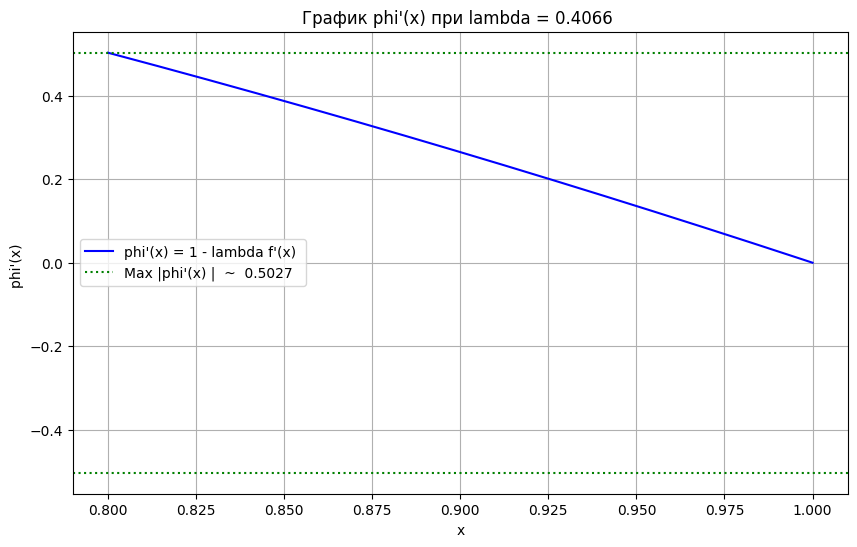

**Расчет для lambda = 0.4066**

Итерация: 1       <br> $x_n$ = 0.8834883455      <br>$|x_n - x_{n-1}$| = 8.3488345494e-02  

Итерация: 2       <br> $x_n$ = 0.9173740124      <br>$|x_n - x_{n-1}$| = 3.3885666863e-02  

Итерация: 3       <br> $x_n$ = 0.9263055555      <br>$|x_n - x_{n-1}$| = 8.9315430945e-03  

Итерация: 4       <br> $x_n$ = 0.9281743851      <br>$|x_n - x_{n-1}$| = 1.8688296582e-03  

...

Итерация: 6       <br> $x_n$ = 0.9286096358      <br>$|x_n - x_{n-1}$| = 7.0237767687e-05  

Итерация: 7       <br> $x_n$ = 0.9286231117      <br>$|x_n - x_{n-1}$| = 1.3475939845e-05  

Итерация: 8       <br> $x_n$ = 0.9286256958      <br>$|x_n - x_{n-1}$| = 2.5840558681e-06  


**Корень: x ≈ 0.92862570**

**Количество итераций: 8**

In [62]:
iter_root_good, iter_count_good = simm(corre_a, epsilon, 1 / M)

### $\lambda$ = 0.527

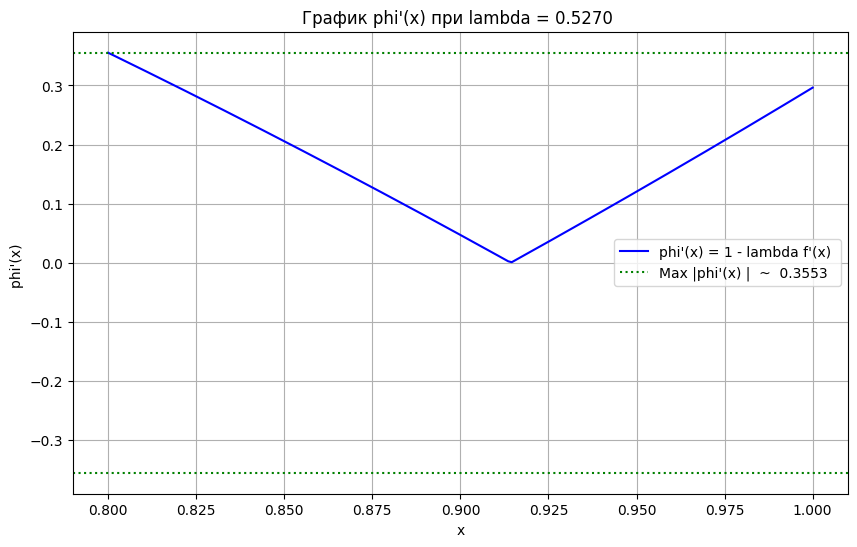

**Расчет для lambda = 0.5270**

Итерация: 1       <br> $x_n$ = 0.9082226599      <br>$|x_n - x_{n-1}$| = 1.0822265990e-01  

Итерация: 2       <br> $x_n$ = 0.9289060851      <br>$|x_n - x_{n-1}$| = 2.0683425150e-02  

Итерация: 3       <br> $x_n$ = 0.9286128231      <br>$|x_n - x_{n-1}$| = 2.9326199697e-04  

Итерация: 4       <br> $x_n$ = 0.9286269521      <br>$|x_n - x_{n-1}$| = 1.4129064583e-05  

Итерация: 5       <br> $x_n$ = 0.9286262780      <br>$|x_n - x_{n-1}$| = 6.7410089233e-07  


**Корень: x ≈ 0.92862628**

**Количество итераций: 5**

In [63]:
iter_root_opt, iter_count_opt = simm(corre_a, epsilon, 0.527)

### $\lambda$ = 0.1

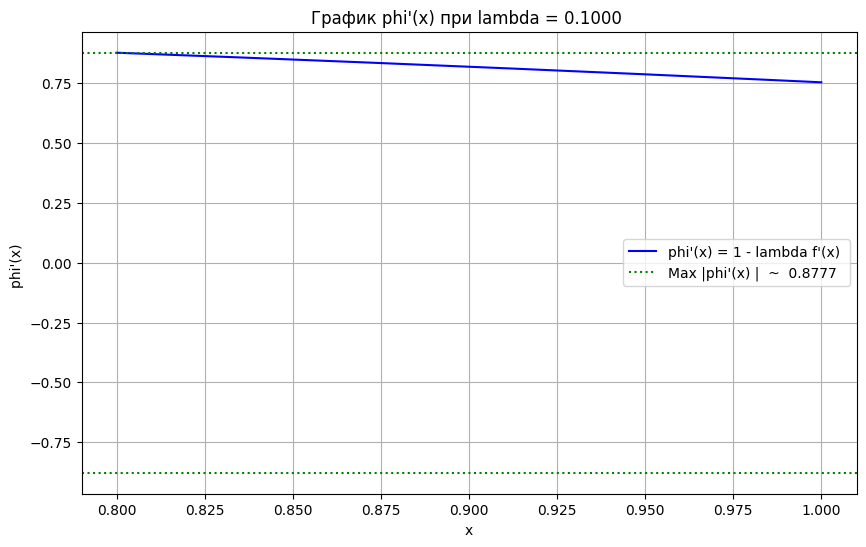

**Расчет для lambda = 0.1000**

Итерация: 1       <br> $x_n$ = 0.8205356091      <br>$|x_n - x_{n-1}$| = 2.0535609090e-02  

Итерация: 2       <br> $x_n$ = 0.8384418083      <br>$|x_n - x_{n-1}$| = 1.7906199219e-02  

Итерация: 3       <br> $x_n$ = 0.8538608530      <br>$|x_n - x_{n-1}$| = 1.5419044687e-02  

Итерация: 4       <br> $x_n$ = 0.8669899960      <br>$|x_n - x_{n-1}$| = 1.3129143017e-02  

...

Итерация: 36      <br> $x_n$ = 0.9285681120      <br>$|x_n - x_{n-1}$| = 1.4439077892e-05  

Итерация: 37      <br> $x_n$ = 0.9285796811      <br>$|x_n - x_{n-1}$| = 1.1569038243e-05  

Итерация: 38      <br> $x_n$ = 0.9285889505      <br>$|x_n - x_{n-1}$| = 9.2693773568e-06  


**Корень: x ≈ 0.92858895**

**Количество итераций: 38**

In [64]:
iter_root_opt, iter_count_opt = simm(corre_a, epsilon, 0.1)

### $\lambda$ = 2

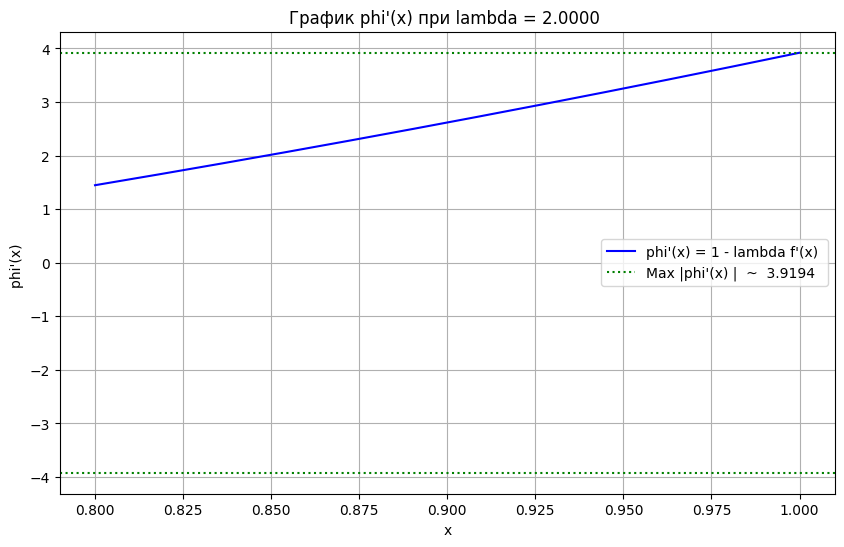

**Расчет для lambda = 2.0000**

Итерация: 1       <br> $x_n$ = 1.2107121818      <br>$|x_n - x_{n-1}$| = 4.1071218180e-01  

Итерация: 2       <br> $x_n$ = -0.4669353769     <br>$|x_n - x_{n-1}$| = 1.6776475587e+00  

Итерация: 3       <br> $x_n$ = -1.1636284851     <br>$|x_n - x_{n-1}$| = 6.9669310815e-01  

Итерация: 4       <br> $x_n$ = 0.1510580467      <br>$|x_n - x_{n-1}$| = 1.3146865318e+00  

...

Итерация: 100     <br> $x_n$ = 0.4240723579      <br>$|x_n - x_{n-1}$| = 2.8040906633e-01  

Итерация: 101     <br> $x_n$ = 1.0944952205      <br>$|x_n - x_{n-1}$| = 6.7042286256e-01  

Превышено максимальное число итераций


**Корень: x ≈ 1.09449522**

**Количество итераций: 101**

In [65]:
iter_root_opt, iter_count_opt = simm(corre_a, epsilon, 2)

## 6.2. Расходящийся процесс

In [66]:
def phi_divergent(x):
    if abs(x**3) >= 1:
        return float('nan')
    return np.arcsin(x**3)

x_prev = 0.9
print("Итерации:")
for i in range(10):
    x_next = phi_divergent(x_prev)
    print(f"Шаг {i+1}: x_{i+1} = {x_next:.8f}")
    x_prev = x_next

Итерации:

Шаг 1: x_1 = 0.81685992

Шаг 2: x_2 = 0.57645836

Шаг 3: x_3 = 0.19275089

Шаг 4: x_4 = 0.00716132

...

Шаг 6: x_6 = 0.00000000

Шаг 7: x_7 = 0.00000000

Шаг 8: x_8 = 0.00000000

Шаг 9: x_9 = 0.00000000

Шаг 10: x_10 = 0.00000000